# Bioactivity QSAR — Acetylcholinesterase Inhibitors

A computational drug-discovery pipeline: pull IC50 bioactivity data from
**ChEMBL**, engineer **Lipinski** descriptors and **PaDEL** PubChem fingerprints,
explore the chemical space, and train a **QSAR regression model** for pIC50.

Reusable logic lives in the `cdd` package (`src/cdd/`); this notebook is the
narrative that drives it. It runs unchanged in **VS Code / local Jupyter** and in
**Google Colab**.

## Setup

In [2]:
# Portable setup: works in VS Code / local Jupyter and in Google Colab.
import sys
from pathlib import Path

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ModuleNotFoundError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/gdrive')
    # Point this at where you copied the project on your Drive:
    PROJECT_ROOT = Path('/gdrive/MyDrive/playground-drug-discovery')
    !pip install -q -r "{PROJECT_ROOT}/requirements.txt"
else:
    # Walk up from the notebook until we find the src/cdd package.
    PROJECT_ROOT = Path.cwd()
    while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / 'src' / 'cdd').exists():
        PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / 'src'))
print('Project root:', PROJECT_ROOT)

Project root: /home/asdf/playground-drug-discovery


In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from cdd import config, data, chem, analysis, features

sns.set_theme(style='ticks')
plt.rcParams['figure.figsize'] = (4, 4)

## 1. Data

The raw ChEMBL query is cached in `data/data_raw.csv` so the notebook runs
offline. Uncomment the live-query block to refresh it from ChEMBL.

In [4]:
# Live query (needs network) — uncomment to re-download:
# targets = data.search_targets()          # find the target...
# raw = data.fetch_bioactivity('CHEMBL220')  # ...then pull its IC50 records
# raw.to_csv(config.RAW_CSV, index=False)

raw = pd.read_csv(config.RAW_CSV)
print(raw.shape)
raw.head(3)

(9415, 46)


,action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,...,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
0,NaN,NaN,33969,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,NaN,NaN,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,NaN,NaN,IC50,uM,UO_0000065,NaN,0.75
1,NaN,NaN,37563,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,NaN,NaN,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,NaN,NaN,IC50,uM,UO_0000065,NaN,0.10
2,NaN,NaN,37565,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,NaN,NaN,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,NaN,NaN,IC50,uM,UO_0000065,NaN,50.00


## 2. Preprocess & feature engineering

Clean the records, label each compound `active`/`inactive` by its IC50, then
add Lipinski descriptors and convert IC50 → pIC50.

In [5]:
clean = data.preprocess(raw)
df = chem.build_features_table(clean)
df.to_csv(config.PREPROCESSED_CSV, index=False)

print(df.shape, '|', df['bioactivity_class'].value_counts().to_dict())
df.head()

(6220, 8) | {'active': 3793, 'inactive': 2427}


,molecule_chembl_id,canonical_smiles,bioactivity_class,MolWt,MolLogP,NumHDonors,NumHAcceptors,pIC50
0,CHEMBL133897,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,active,312.325,2.8032,0,6,6.124939
1,CHEMBL336398,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1,active,376.913,4.5546,0,5,7.000000
2,CHEMBL131588,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1,inactive,426.851,5.3574,0,5,4.301030
3,CHEMBL130628,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F,active,404.845,4.7069,0,5,6.522879
4,CHEMBL130478,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C,active,346.334,3.0953,0,6,6.096910


## 3. Exploratory analysis

Class balance, chemical space (MW vs LogP), and a Mann-Whitney U test on each
descriptor to see which differ significantly between active and inactive
compounds. Plots are saved to `plots/`.

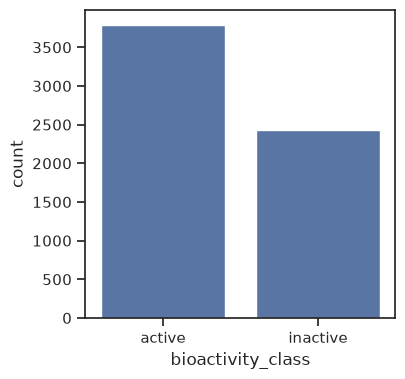

In [6]:
analysis.plot_bioactivity_counts(df);

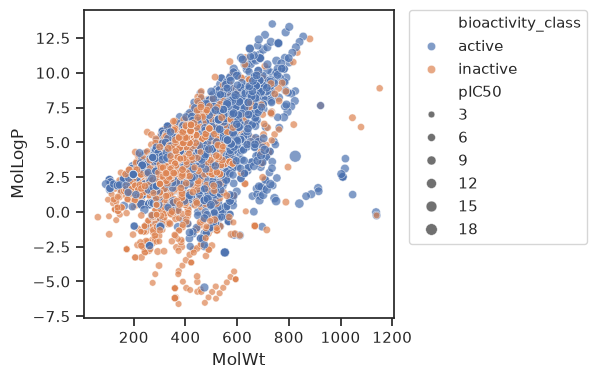

In [7]:
analysis.plot_mw_vs_logp(df);

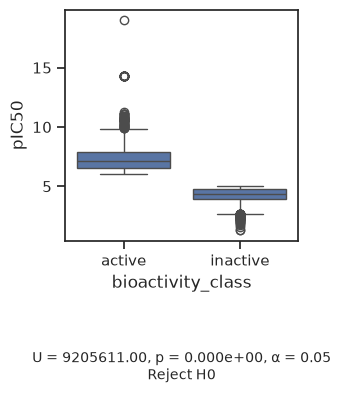

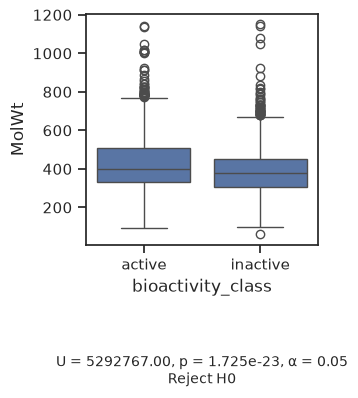

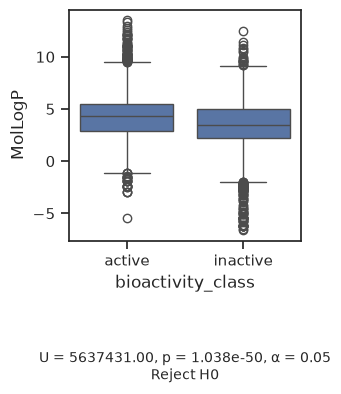

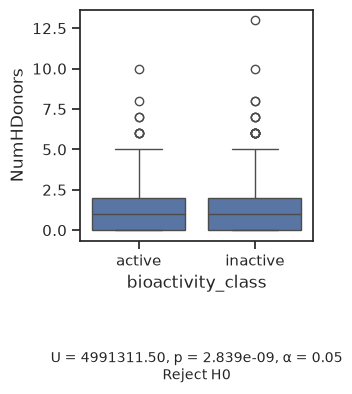

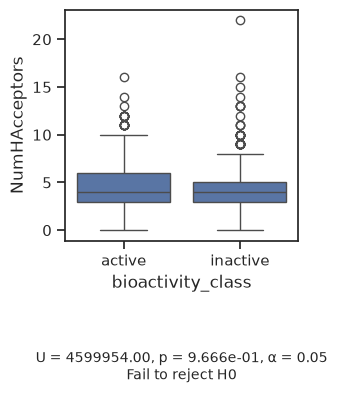

In [8]:
for descriptor in ['pIC50', *config.LIPINSKI_DESCRIPTORS]:
    analysis.plot_descriptor(df, descriptor)
    plt.show()

`MolWt`, `MolLogP`, and `NumHDonors` differ significantly between the two
classes (reject H0); `NumHAcceptors` does not.

## 4. Fingerprints (PaDEL)

881-bit PubChem fingerprints are the model inputs. The output is cached in
`data/PaDEL_descriptors_output.csv`, so the calculation below is optional
(it needs Java). `prepare_xy` aligns fingerprints to labels **by molecule id**,
since PaDEL does not preserve input row order.

In [9]:
# Recompute fingerprints (needs Java) — uncomment to regenerate:
# smi = features.write_smi(df)
# features.compute_padel_fingerprints(smi)

fingerprints = features.load_fingerprints()
X, y = features.prepare_xy(df, fingerprints)
print('X:', X.shape, '| y:', y.shape)

X: (6220, 137) | y: (6220,)


## 5. Model

First screen many regressors with **LazyPredict**, then train the selected
**Random Forest** QSAR model.

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)

In [11]:
# Broad model comparison (optional, slow):
from lazypredict.Supervised import LazyRegressor

reg = LazyRegressor(verbose=0, ignore_warnings=True, custom_metric=None)
train_scores, test_scores = reg.fit(X_train, X_test, y_train, y_test)
train_scores.head(10)

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
RandomForestRegressor,0.696561,0.730005,0.928579,2.778666
BaggingRegressor,0.679437,0.714769,0.954421,0.335073
HistGradientBoostingRegressor,0.672762,0.708829,0.964308,0.754507
MLPRegressor,0.624115,0.665544,1.033501,67.481587
SVR,0.599482,0.643626,1.066828,1.372943
NuSVR,0.590210,0.635376,1.079106,1.214826
ExtraTreesRegressor,0.559380,0.607944,1.118962,4.575932
KNeighborsRegressor,0.553258,0.602497,1.126709,0.098305
DecisionTreeRegressor,0.520788,0.573605,1.166937,0.092867


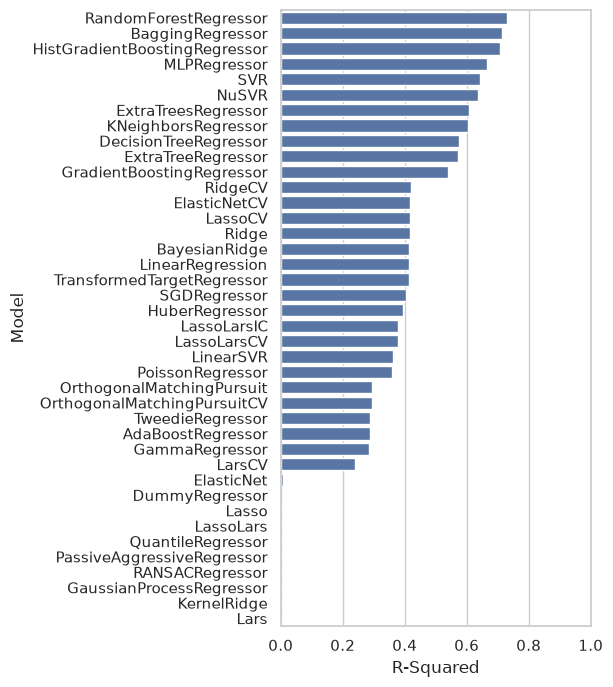

In [12]:
plt.figure(figsize=(4, 8))
sns.set_theme(style='whitegrid')
ax = sns.barplot(y=train_scores.index, x='R-Squared', data=train_scores)
ax.set(xlim=(0, 1));

### Train the selected model (Random Forest)

In [13]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=100)
model.fit(X_train, y_train)
print('Test R2:', round(model.score(X_test, y_test), 3))

Test R2: 0.732


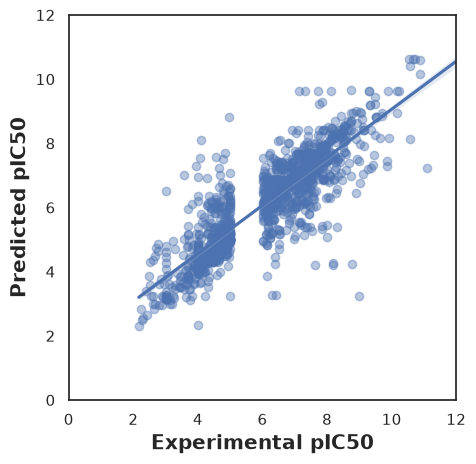

In [14]:
y_pred = model.predict(X_test)

sns.set_style('white')
ax = sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha': 0.4})
ax.set_xlabel('Experimental pIC50', fontsize='large', fontweight='bold')
ax.set_ylabel('Predicted pIC50', fontsize='large', fontweight='bold')
ax.set_xlim(0, 12); ax.set_ylim(0, 12)
ax.figure.set_size_inches(5, 5)
plt.show()